In [116]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report



In [117]:
df = pd.read_csv("heart.csv")

In [118]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,1,0,166,274,0,1,139,0,2.7,1,0,3,0
1,57,1,0,146,206,1,0,157,1,0.9,1,2,2,0
2,43,0,2,102,340,0,0,171,1,5.5,1,1,2,1
3,71,1,3,167,499,0,0,78,0,2.1,2,1,2,1
4,36,1,0,145,323,0,0,147,0,1.0,2,0,2,0


In [119]:
df.shape

(303, 14)

In [120]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [122]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,52.267327,0.643564,0.907591,145.943894,345.792079,0.165017,0.544554,139.132013,0.326733,3.048845,1.161716,0.640264,2.306931,0.541254
std,13.896179,0.479738,0.995707,30.070890,128.117779,0.371809,0.549378,38.694367,0.469794,1.792753,0.734838,0.894777,0.626288,0.499120
min,29.000000,0.000000,0.000000,94.000000,128.000000,0.000000,0.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,0.000000,0.000000,121.500000,233.000000,0.000000,0.000000,105.500000,0.000000,1.700000,1.000000,0.000000,2.000000,0.000000
50%,53.000000,1.000000,1.000000,146.000000,351.000000,0.000000,1.000000,140.000000,0.000000,3.000000,1.000000,0.000000,2.000000,1.000000
75%,64.000000,1.000000,2.000000,174.000000,459.000000,0.000000,1.000000,175.500000,1.000000,4.600000,2.000000,1.000000,3.000000,1.000000
max,76.000000,1.000000,3.000000,199.000000,562.000000,1.000000,2.000000,201.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [123]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [124]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 13)
Target shape: (303,)


In [125]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (242, 13)
X_test: (61, 13)
y_train: (242,)
y_test: (61,)


In [126]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [127]:
y_pred = model.predict(X_test)

print("Predictions:", y_pred[:10])
print("Actual values:", y_test.iloc[:10].values)

Predictions: [1 0 1 1 1 1 1 0 0 0]
Actual values: [1 0 1 1 1 1 1 0 0 1]


In [128]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9672131147540983
Accuracy (%): 96.72131147540983


[[23  1]
 [ 1 36]]


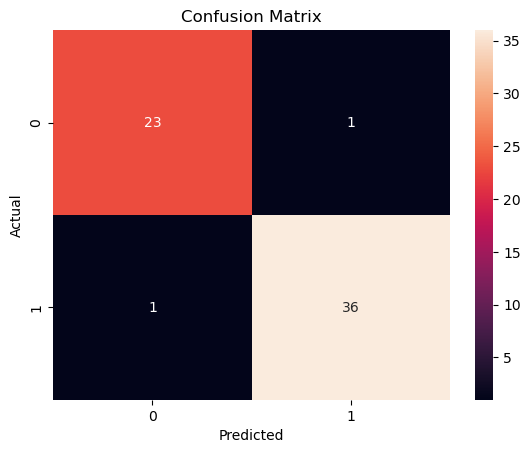

In [129]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [130]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        24
           1       0.97      0.97      0.97        37

    accuracy                           0.97        61
   macro avg       0.97      0.97      0.97        61
weighted avg       0.97      0.97      0.97        61



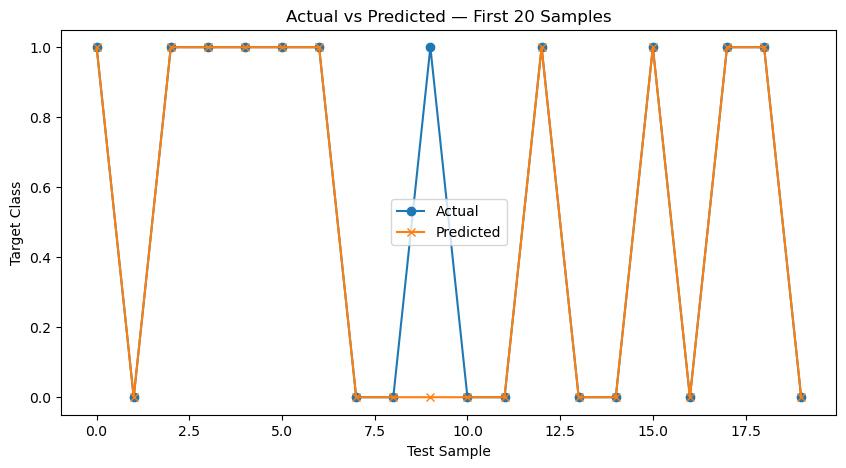

In [131]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.values[:20], marker="o", label="Actual")
plt.plot(y_pred[:20], marker="x", label="Predicted")

plt.xlabel("Test Sample")
plt.ylabel("Target Class")
plt.title("Actual vs Predicted — First 20 Samples")
plt.legend()
plt.show()

## Conclusion

In this project, I used Logistic Regression to classify heart disease data into two target classes.

The dataset was split into 80% training data and 20% testing data. The model achieved approximately **97% accuracy** on the test set.

I evaluated the model using accuracy, confusion matrix, precision, recall, and F1-score. These metrics helped me understand the model's classification performance.

## Model Limitations

* The model uses only the features available in the given dataset.
* The dataset is relatively small, with 303 records.
* The model's performance may change on different or unseen datasets.
* High test accuracy does not guarantee reliable predictions for real patients.
* This project is for educational purposes and is not intended for medical diagnosis.
